In [4]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [5]:
import yfinance as yf
import pandas as pd

data = yf.download("SPY", start="2015-01-01", end="2026-08-01", progress=False)

# Flatten the MultiIndex columns down to simple names
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.shape)
print(data.head())

(2911, 5)
Price            Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687820  170.885549  168.655304  170.472543  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053940  167.449373  164.260962  166.928980  209151400
2015-01-07  167.110672  167.449340  165.929480  166.375521  125346700
2015-01-08  170.076096  170.290867  168.498420  168.514931  147217800


In [6]:
data.to_csv(ROOT / "data" / "raw" / "spy_raw.csv")
print(f"Saved {len(data)} rows to data/raw/spy_raw.csv")

Saved 2911 rows to data/raw/spy_raw.csv


Data Source & Validation
Source: Yahoo Finance, via the yfinance Python library (API pull, no manual download or key required)
Ticker: SPY
Date range: 2015-01-01 to 2026-08-01
Rows: 2,911
Validation: no missing values found (see check below); date range and row count consistent with expected trading days over this period

In [7]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [8]:
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.append(str(ROOT / "src"))
from utils import save_raw_data, load_raw_data

# Save using the new env-driven function
save_raw_data(data, "spy_raw.csv")

# Reload to confirm it round-trips correctly
reloaded = load_raw_data("spy_raw.csv")
print(reloaded.head())

Saved 2911 rows to data/raw/spy_raw.csv
Loaded 2911 rows from data/raw/spy_raw.csv
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687820  170.885549  168.655304  170.472543  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053940  167.449373  164.260962  166.928980  209151400
2015-01-07  167.110672  167.449340  165.929480  166.375521  125346700
2015-01-08  170.076096  170.290867  168.498420  168.514931  147217800


In [9]:
sys.path.append(str(ROOT / "src"))
from cleaning import preprocess_pipeline

raw = load_raw_data("spy_raw.csv")
processed = preprocess_pipeline(raw)

processed.to_csv(ROOT / "data" / "processed" / "spy_processed.csv")
print(f"Saved {len(processed)} processed rows")
print(processed.head())

Loaded 2911 rows from data/raw/spy_raw.csv
Removed 0 duplicate rows
Filled 0 missing values via forward-fill
Saved 2911 processed rows
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687820  170.885549  168.655304  170.472543  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053940  167.449373  164.260962  166.928980  209151400
2015-01-07  167.110672  167.449340  165.929480  166.375521  125346700
2015-01-08  170.076096  170.290867  168.498420  168.514931  147217800


Preprocessing assumptions: Missing values are forward-filled, assuming the last known price holds until new data arrives (standard for financial time series, avoids fabricating values). Duplicate dates are dropped, keeping the first occurrence. Data is sorted chronologically to support time-series modeling in later stages.

In [10]:
sys.path.append(str(ROOT / "src"))
from outliers import detect_outliers_zscore, remove_outliers

flagged = detect_outliers_zscore(processed)
print(flagged[flagged["is_outlier"]][["Close"]])

Flagged 39 outliers out of 2911 rows (1.34%)
                 Close
Date                  
2015-08-24  157.992981
2015-08-26  162.128281
2016-06-24  173.122574
2018-02-05  231.705231
2018-02-08  226.174454
2018-12-26  220.227661
2020-02-24  293.892059
2020-02-27  271.186096
2020-03-02  281.741455
2020-03-04  285.177917
2020-03-05  275.698181
2020-03-09  249.965942
2020-03-10  262.900421
2020-03-11  250.084503
2020-03-12  226.157089
2020-03-13  245.490417
2020-03-16  218.627945
2020-03-17  230.432114
2020-03-18  218.764618
2020-03-20  209.782013
2020-03-24  222.939209
2020-03-26  239.488907
2020-04-01  225.689850
2020-04-06  242.844666
2020-06-11  275.623077
2020-09-03  318.074585
2020-10-28  302.030029
2022-04-29  388.862976
2022-05-05  390.571381
2022-05-18  369.853943
2022-06-13  353.940826
2022-06-16  346.059753
2022-08-26  384.201111
2022-09-13  372.627106
2022-11-10  375.671112
2025-04-03  529.253784
2025-04-04  498.269684
2025-04-09  541.008484
2025-04-10  517.301880


In [11]:
sys.path.append(str(ROOT / "src"))
from eda import eda_summary
import matplotlib.pyplot as plt

summary_stats = eda_summary(processed)

mean_price: 354.620122
median_price: 317.637238
std_price: 158.715464
min_price: 154.161606
max_price: 757.618225
missing_values: 0
mean_daily_return: 0.000571
std_daily_return: 0.011097
skewness_returns: -0.307511


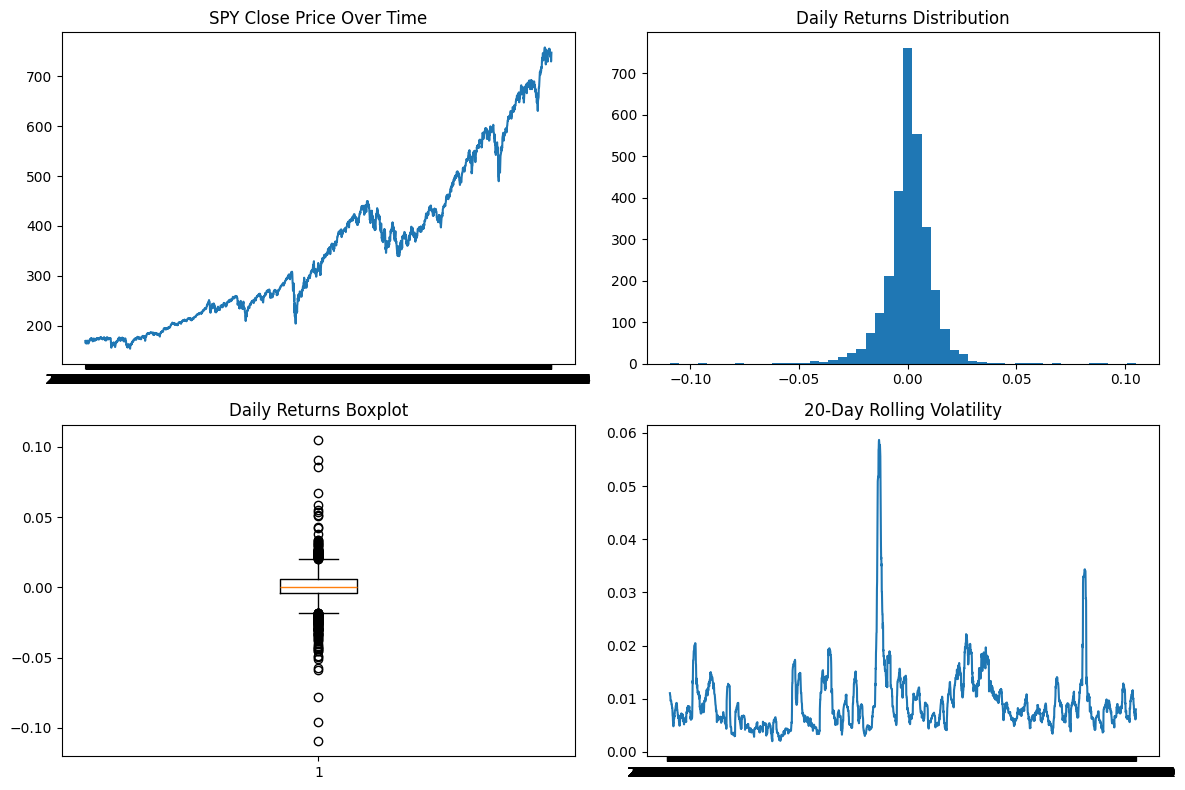

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time series
axes[0, 0].plot(processed.index, processed["Close"])
axes[0, 0].set_title("SPY Close Price Over Time")

# Returns histogram
returns = processed["Close"].pct_change().dropna()
axes[0, 1].hist(returns, bins=50)
axes[0, 1].set_title("Daily Returns Distribution")

# Boxplot - shows outliers visually
axes[1, 0].boxplot(returns)
axes[1, 0].set_title("Daily Returns Boxplot")

# Rolling volatility (bonus insight, cheap to add)
rolling_vol = returns.rolling(20).std()
axes[1, 1].plot(processed.index[1:], rolling_vol)
axes[1, 1].set_title("20-Day Rolling Volatility")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "eda_summary.png")
plt.show()